In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'computers.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(480, 640, 3)

In [3]:
def homography(src, dst):
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y])
        b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y])
        b.append(v)
    h = np.linalg.solve(np.array(A, dtype=np.float64), np.array(b, dtype=np.float64))
    return np.append(h, 1).reshape(3, 3)

In [4]:
left = img[:, :400]
right = img[:, 240:]

H_true = np.array([[0.95, 0.05, 15], [-0.04, 0.98, 10], [0.0001, 0.00005, 1]])
right_cam = cv2.warpPerspective(right, H_true, (460, 500))

pts = np.float64([[260, 60], [380, 60], [380, 420], [260, 420]])
shifted = np.hstack([pts - [240, 0], np.ones((4, 1))]) @ H_true.T
right_pts = np.round(shifted[:, :2] / shifted[:, 2:])
right_pts

array([[ 37.,  68.],
       [148.,  62.],
       [163., 402.],
       [ 54., 411.]])

In [5]:
H = homography(right_pts, pts)

panorama = cv2.warpPerspective(right_cam, H, (img.shape[1], img.shape[0]))
panorama[:, :left.shape[1]] = left

print(np.round(H, 4))

[[ 1.03970e+00 -6.42000e-02  2.24295e+02]
 [ 5.02000e-02  1.02020e+00 -1.15997e+01]
 [-1.00000e-04 -0.00000e+00  1.00000e+00]]


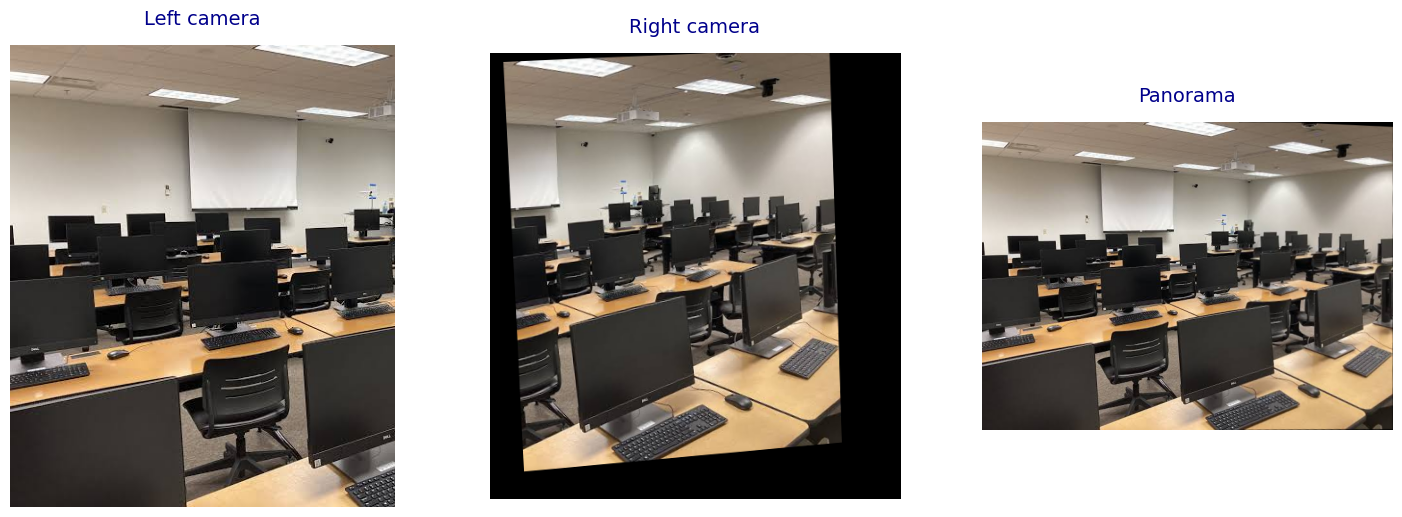

In [6]:
panels = [('Left camera', left), ('Right camera', right_cam), ('Panorama', panorama)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task9_panorama.png', cv2.cvtColor(panorama, cv2.COLOR_RGB2BGR))

True

4 matching points from the overlap are used, the 4 corners of a box in the middle. In the left image they are plain coordinates, in the right one they are where the same points show up in that camera.

H maps points of the right image into the left image's space. warpPerspective with H puts the whole right image on the left camera's canvas and then the left image is pasted over its part. Overlap lines up since the 4 points do, but the seam is visible where one image stops and the other starts. Blending would be needed to hide it.